# Week 6 lab: Neural networks (MLP)

AIE683 Machine Learning. This notebook contains the worked examples from the slides and three in-class exercises
("Try it" 1-3). Run it top to bottom with `uv run jupyter lab` from the repository root; total runtime is a few minutes on a laptop CPU.

Contents
1. MLPs in scikit-learn (two moons, input scaling, early stopping)
2. A PyTorch training loop on California housing
3. Logging training curves to MLflow
4. MLP vs gradient boosting
5. Try it 1: can an MLP beat logistic regression on credit risk?
6. Try it 2: find the bugs in a training loop
7. Try it 3: predict the winner (covertype)

Cells marked **TODO** are yours to edit. As provided, they run without errors.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")  # keeps scikit-learn and PyTorch from oversubscribing CPU cores
import copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import mlflow
from sklearn.datasets import make_moons, load_breast_cancer, fetch_california_housing, fetch_openml, fetch_covtype
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
torch.set_num_threads(2)
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
mlflow.set_experiment("week06-neural-networks")
print("torch", torch.__version__, "| mlflow", mlflow.__version__)

/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/30 00:04:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/30 00:04:33 INFO mlflow.store.db.utils: Updating database tables


2026/09/30 00:04:34 INFO mlflow.tracking.fluent: Experiment with name 'week06-neural-networks' does not exist. Creating a new experiment.


torch 2.14.0 | mlflow 3.16.1


## 1. MLPs in scikit-learn
Decision boundaries on two moons for three configurations.

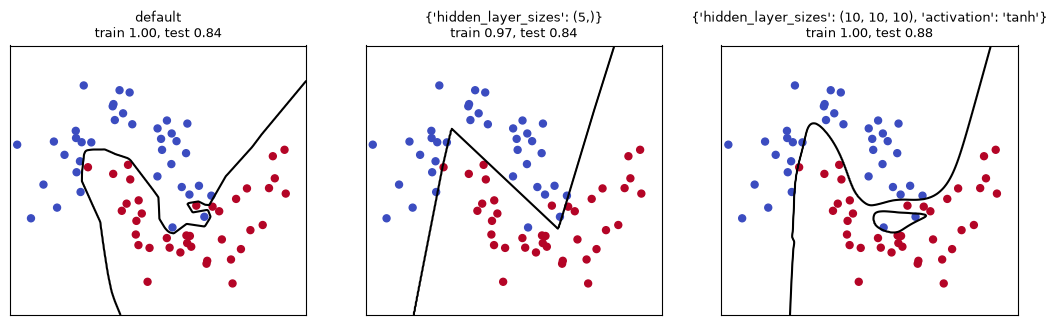

In [2]:
X, y = make_moons(n_samples=100, noise=0.25, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

xx, yy = np.meshgrid(np.linspace(-1.6, 2.6, 300), np.linspace(-1.2, 1.7, 300))
X_grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
configs = [{}, {"hidden_layer_sizes": (5,)}, {"hidden_layer_sizes": (10, 10, 10), "activation": "tanh"}]
for ax, kw in zip(axes, configs):
    mlp = MLPClassifier(solver="lbfgs", max_iter=1000, random_state=0, **kw).fit(X_train, y_train)
    ax.contour(xx, yy, mlp.predict_proba(X_grid)[:, 1].reshape(xx.shape), levels=[.5], colors="k")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=25)
    ax.set_title(f"{kw or 'default'}\ntrain {mlp.score(X_train, y_train):.2f}, test {mlp.score(X_test, y_test):.2f}", fontsize=9)
    ax.set_xticks(()); ax.set_yticks(())

Input scaling: the same MLP on raw and standardized breast cancer features.

raw features:   test accuracy 0.923
StandardScaler: test accuracy 0.958


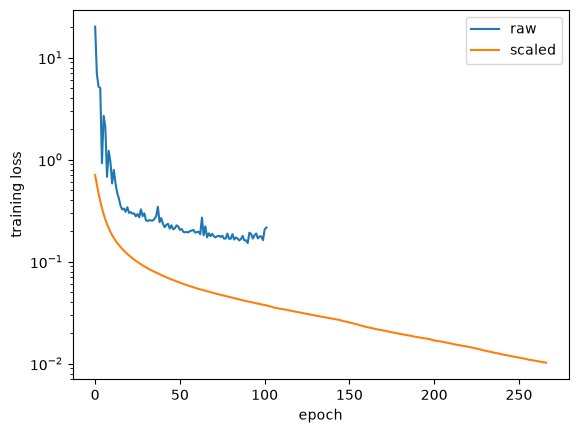

In [3]:
# Input scaling matters: same network, raw vs standardized features
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, stratify=data.target, random_state=0)
raw = MLPClassifier(max_iter=300, random_state=0).fit(X_train, y_train)
scaled = make_pipeline(StandardScaler(), MLPClassifier(max_iter=300, random_state=0)).fit(X_train, y_train)
print(f"raw features:   test accuracy {raw.score(X_test, y_test):.3f}")
print(f"StandardScaler: test accuracy {scaled.score(X_test, y_test):.3f}")
plt.plot(raw.loss_curve_, label="raw")
plt.plot(scaled[-1].loss_curve_, label="scaled")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("training loss"); plt.legend();

Regularization: grid search over the L2 penalty `alpha`, and built-in early stopping.

In [4]:
# L2 penalty (alpha) and built-in early stopping
pipe = make_pipeline(StandardScaler(), MLPClassifier(solver="lbfgs", max_iter=2000, random_state=1))
grid = GridSearchCV(pipe, {"mlpclassifier__alpha": np.logspace(-3, 3, 7)}, return_train_score=True).fit(X_train, y_train)
res = pd.DataFrame(grid.cv_results_)[["param_mlpclassifier__alpha", "mean_train_score", "mean_test_score", "std_test_score"]]
print(res.round(3).to_string(index=False))

es = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(100, 100), early_stopping=True,
                                                   n_iter_no_change=10, max_iter=500, random_state=0)).fit(X_train, y_train)
print("early stopping after", es[-1].n_iter_, "epochs; test accuracy", round(es.score(X_test, y_test), 3))

 param_mlpclassifier__alpha  mean_train_score  mean_test_score  std_test_score
                      0.001             1.000            0.981           0.006
                      0.010             1.000            0.981           0.006
                      0.100             1.000            0.974           0.009
                      1.000             0.999            0.979           0.012
                     10.000             0.991            0.984           0.012
                    100.000             0.947            0.939           0.034
                   1000.000             0.627            0.627           0.005
early stopping after 35 epochs; test accuracy 0.958


## 2. A PyTorch training loop
Data as float32 tensors; the scaler is fitted on the training split only.

In [5]:
X, y = fetch_california_housing(return_X_y=True)          # 20 640 districts, 8 features, target in $100k
X_trval, X_test, y_trval, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_trval, y_trval, test_size=0.2, random_state=0)

scaler = StandardScaler().fit(X_train)                     # fit on training data only
def to_t(X, y, scale=True):
    Xs = scaler.transform(X) if scale else X
    return (torch.tensor(Xs, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1))   # target shape (n, 1)

Xtr, ytr = to_t(X_train, y_train); Xva, yva = to_t(X_val, y_val); Xte, yte = to_t(X_test, y_test)
print(Xtr.shape, ytr.shape, Xva.shape, Xte.shape)

torch.Size([13209, 8]) torch.Size([13209, 1]) torch.Size([3303, 8]) torch.Size([4128, 8])


The 8 → 128 → 128 → 1 network with dropout (17 793 parameters).

In [6]:
def make_mlp(n_in, hidden=(128, 128), dropout=0.1):
    layers, d = [], n_in
    for h in hidden:
        layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
        d = h
    layers.append(nn.Linear(d, 1))                 # identity output for regression
    return nn.Sequential(*layers)

model = make_mlp(X.shape[1])
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Linear(in_features=8, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=128, out_features=1, bias=True)
)
parameters: 17793


Training loop with mini-batches, AdamW, dropout and early stopping (restores the best weights).

In [7]:
def fit(model, opt, Xtr, ytr, Xva, yva, epochs=150, patience=10, batch_size=256):
    """Mini-batch training with early stopping; returns per-epoch history and the best epoch."""
    torch.manual_seed(SEED)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    loss_fn = nn.MSELoss()
    hist = {"train": [], "val": []}
    best_val, best_state, best_epoch = float("inf"), None, 0
    for epoch in range(epochs):
        model.train()                               # dropout on
        total = 0.0
        for xb, yb in loader:
            opt.zero_grad()                         # clear old gradients
            loss = loss_fn(model(xb), yb)           # forward pass
            loss.backward()                         # backward pass
            opt.step()                              # parameter update
            total += loss.item() * len(xb)
        model.eval()                                # dropout off
        with torch.no_grad():
            val = loss_fn(model(Xva), yva).item()
        hist["train"].append(total / len(Xtr)); hist["val"].append(val)
        if val < best_val:
            best_val, best_state, best_epoch = val, copy.deepcopy(model.state_dict()), epoch
        elif epoch - best_epoch >= patience:
            break                                   # early stopping
    model.load_state_dict(best_state)               # restore best weights
    return hist, best_epoch

def plot_hist(hist, best_epoch=None, title=""):
    ep = range(1, len(hist["train"]) + 1)
    plt.plot(ep, hist["train"], label="train"); plt.plot(ep, hist["val"], label="validation")
    if best_epoch is not None:
        plt.axvline(best_epoch + 1, ls="--", c="gray")
    plt.ylim(0.15, 1.0); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title(title); plt.legend()

stopped after 78 epochs, best epoch 68, test R2 = 0.788, 2.8s


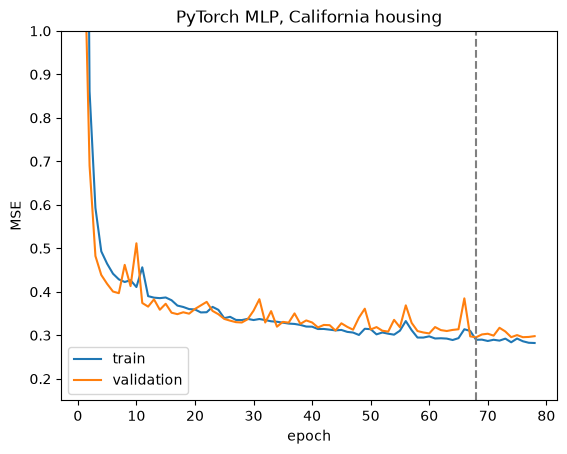

In [8]:
torch.manual_seed(SEED)
model = make_mlp(X.shape[1])
params = {"hidden": "128-128", "dropout": 0.1, "lr": 1e-3, "weight_decay": 1e-4,
          "batch_size": 256, "optimizer": "AdamW", "patience": 10, "seed": SEED}
opt = torch.optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
t0 = time.perf_counter()
hist, best_epoch = fit(model, opt, Xtr, ytr, Xva, yva)
torch_time = time.perf_counter() - t0
with torch.no_grad():
    test_r2 = r2_score(y_test, model(Xte).numpy().ravel())
print(f"stopped after {len(hist['val'])} epochs, best epoch {best_epoch + 1}, test R2 = {test_r2:.3f}, {torch_time:.1f}s")
plot_hist(hist, best_epoch, "PyTorch MLP, California housing")

## 3. Log the run to MLflow
Per-epoch metrics use `step=` so the MLflow UI shows them as curves.

In [9]:
with mlflow.start_run(run_name="torch-mlp-adamw"):
    mlflow.log_params(params)
    for epoch in range(len(hist["val"])):
        mlflow.log_metrics({"train_loss": hist["train"][epoch], "val_loss": hist["val"][epoch]}, step=epoch)
    mlflow.log_metrics({"best_epoch": best_epoch, "test_r2": test_r2, "fit_seconds": torch_time})
print("Logged. Inspect with: uv run mlflow ui  (run it in the folder that contains mlflow.db)")

Logged. Inspect with: uv run mlflow ui  (run it in the folder that contains mlflow.db)


## 4. MLP vs gradient boosting on the same split

In [10]:
models = {"Ridge": make_pipeline(StandardScaler(), RidgeCV()),
          "MLPRegressor": make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(128, 128),
                                        early_stopping=True, max_iter=300, random_state=0)),
          "HistGradientBoosting": HistGradientBoostingRegressor(random_state=0)}
rows = []
for name, est in models.items():
    t0 = time.perf_counter(); est.fit(X_trval, y_trval); secs = time.perf_counter() - t0
    rows.append({"model": name, "test_r2": r2_score(y_test, est.predict(X_test)), "fit_s": secs})
rows.append({"model": "PyTorch MLP", "test_r2": test_r2, "fit_s": torch_time})
comparison = pd.DataFrame(rows).sort_values("test_r2")
with mlflow.start_run(run_name="california-comparison"):
    for r in rows:
        mlflow.log_metric(f"test_r2_{r['model']}", r["test_r2"])
comparison.round(3)

,model,test_r2,fit_s
0,Ridge,0.594,0.004
1,MLPRegressor,0.787,2.087
3,PyTorch MLP,0.788,2.806
2,HistGradientBoosting,0.837,0.105


## Try it 1: can an MLP beat logistic regression on credit risk? (12 min)

German credit data: 1 000 loan applicants, 20 features (13 categorical), target = bad credit risk.

1. **Before running anything**, write your prediction in the next cell.
2. Build a pipeline `preprocess -> MLPClassifier` and compare it with the logistic regression baseline (5-fold CV, ROC AUC).
3. Tune `alpha` and `hidden_layer_sizes` with `GridSearchCV`. Is the best MLP better than logistic regression by more than one standard deviation?

In [11]:
# TODO: your prediction (edit the string)
my_prediction_try1 = "MLP AUC will be ... compared with logistic regression"

In [12]:
Xc, yc = fetch_openml("credit-g", version=1, as_frame=True, return_X_y=True)
yc = (yc == "bad").astype(int)
preprocess = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include="category")),
    (StandardScaler(), make_column_selector(dtype_include="number")))
cv = StratifiedKFold(5, shuffle=True, random_state=0)
logreg = make_pipeline(preprocess, LogisticRegression(max_iter=1000))
s = cross_val_score(logreg, Xc, yc, cv=cv, scoring="roc_auc")
print(f"logistic regression ROC AUC: {s.mean():.3f} +/- {s.std():.3f}")

logistic regression ROC AUC: 0.791 +/- 0.024


In [13]:
# TODO: build an MLP pipeline and a parameter grid, then run the grid search.
# Hint: solver="lbfgs" works well on 1 000 rows; try alpha on a log scale and a few hidden_layer_sizes.
mlp_pipe = make_pipeline(preprocess, MLPClassifier(max_iter=500, random_state=0))
param_grid = {}   # e.g. {"mlpclassifier__alpha": [...], "mlpclassifier__hidden_layer_sizes": [...]}

grid1 = GridSearchCV(mlp_pipe, param_grid, cv=cv, scoring="roc_auc").fit(Xc, yc)
print("best params:", grid1.best_params_)
print(f"best MLP ROC AUC: {grid1.best_score_:.3f} +/- {grid1.cv_results_['std_test_score'][grid1.best_index_]:.3f}")

best params: {}
best MLP ROC AUC: 0.763 +/- 0.039


## Try it 2: find the bugs (12 min)

`buggy_train()` trains the California housing MLP. It runs without errors, but it contains **three bugs**.

1. Run it and look at the curves. What looks wrong?
2. Find the three bugs (the "What goes wrong in practice" slide helps).
3. Fix them one at a time in `fixed_train()` and log each version with `log_run(...)`, then compare the curves in the MLflow UI.

Target: validation MSE below 0.35.

final validation MSE: 1.472


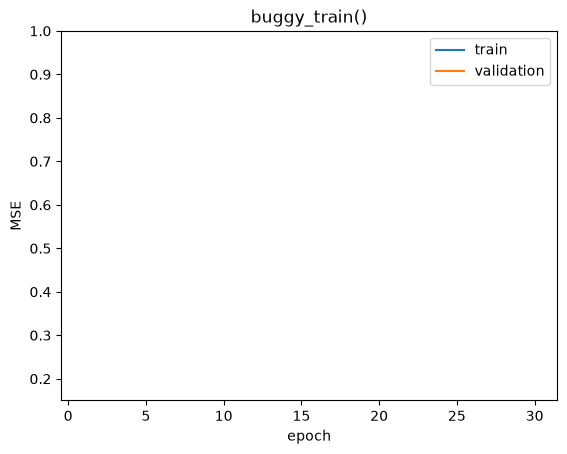

In [14]:
# Unscaled tensors for the exercise (do not edit this cell)
Xtr_raw, ytr_raw = to_t(X_train, y_train, scale=False)
Xva_raw, yva_raw = to_t(X_val, y_val, scale=False)

def buggy_train(epochs=30, lr=1e-3):
    torch.manual_seed(SEED)
    model = make_mlp(X.shape[1], dropout=0.3)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loader = DataLoader(TensorDataset(Xtr_raw, ytr_raw), batch_size=256, shuffle=True)
    loss_fn = nn.MSELoss()
    hist = {"train": [], "val": []}
    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, yb in loader:
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item() * len(xb)
        with torch.no_grad():
            val = loss_fn(model(Xva_raw), yva_raw).item()
        hist["train"].append(total / len(Xtr_raw)); hist["val"].append(val)
    return hist

def log_run(name, hist):
    with mlflow.start_run(run_name=name):
        for epoch in range(len(hist["val"])):
            mlflow.log_metrics({"train_loss": hist["train"][epoch], "val_loss": hist["val"][epoch]}, step=epoch)
        mlflow.log_metric("final_val_loss", hist["val"][-1])

hist_buggy = buggy_train()
log_run("try2-buggy", hist_buggy)
print(f"final validation MSE: {hist_buggy['val'][-1]:.3f}")
plot_hist(hist_buggy, title="buggy_train()")

final validation MSE: 1.472


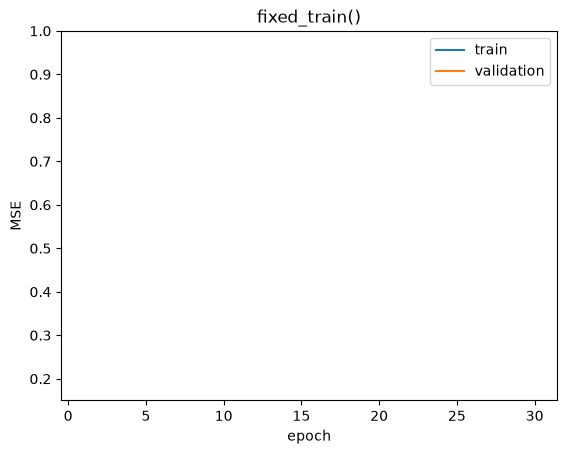

In [15]:
# TODO: copy buggy_train here, fix the three bugs (one at a time), and log each version.
def fixed_train(epochs=30, lr=1e-3):
    return buggy_train(epochs, lr)   # replace with your fixed loop

hist_fixed = fixed_train()
log_run("try2-fixed", hist_fixed)
print(f"final validation MSE: {hist_fixed['val'][-1]:.3f}")
plot_hist(hist_fixed, title="fixed_train()")

## Try it 3: predict the winner, then run it (12 min)

Forest cover type: 54 cartographic features (10 numeric, 44 binary), 7 classes. We use a 30 000-row subsample:
20 000 for training (of which 20% for validation) and 10 000 held-out test rows.

1. **Predict first**: MLP or `HistGradientBoostingClassifier`, and by how much?
2. Run both templates (each fits in a few seconds).
3. Make **one** change to improve the MLP (or the boosting model) using the *validation* accuracy only.
   Keep fitting time under 2 minutes. Evaluate on the test set once, at the very end.

In [16]:
# TODO: your prediction (edit the string)
my_prediction_try3 = "... will win by about ... accuracy points"

In [17]:
Xf, yf = fetch_covtype(return_X_y=True)
Xf, _, yf, _ = train_test_split(Xf, yf, train_size=30000, stratify=yf, random_state=0)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(Xf, yf, test_size=10000, stratify=yf, random_state=0)
Xf_tr, Xf_val, yf_tr, yf_val = train_test_split(Xf_train, yf_train, test_size=0.2, stratify=yf_train, random_state=0)
print(Xf_tr.shape, Xf_val.shape, Xf_test.shape, "classes:", np.unique(yf))

def evaluate(name, est):
    t0 = time.perf_counter(); est.fit(Xf_tr, yf_tr); secs = time.perf_counter() - t0
    acc = est.score(Xf_val, yf_val)
    print(f"{name:35s} validation accuracy {acc:.3f}  ({secs:.1f}s)")
    return est

mlp_cov = evaluate("MLP (128, 128), 40 epochs",
                   make_pipeline(StandardScaler(), MLPClassifier((128, 128), max_iter=40, random_state=0)))
hgb_cov = evaluate("HistGradientBoosting (default)", HistGradientBoostingClassifier(random_state=0))

(16000, 54) (4000, 54) (10000, 54) classes: [1 2 3 4 5 6 7]


MLP (128, 128), 40 epochs           validation accuracy 0.801  (1.4s)


HistGradientBoosting (default)      validation accuracy 0.821  (2.1s)


In [18]:
# TODO: one change to improve a model, judged on validation accuracy. Then evaluate your final choice on test ONCE.
my_model = evaluate("my model", make_pipeline(StandardScaler(), MLPClassifier((128, 128), max_iter=40, random_state=0)))

final = my_model
print(f"TEST accuracy of the final model: {final.score(Xf_test, yf_test):.3f}")

my model                            validation accuracy 0.801  (1.5s)
TEST accuracy of the final model: 0.794
